In [2]:
import pandas as pd
import numpy as np
import os
import time
import requests
from io import StringIO
import warnings

warnings.filterwarnings('ignore')

## 1. Загрузка матчей и маппинг ID → имя

In [3]:
# Загружаем обработанный датасет и фильтруем 2017-2024
df = pd.read_csv("norm_dataframe.csv")
df['tourney_date'] = pd.to_datetime(df['tourney_date'])
df = df[(df['tourney_date'] >= '2017-01-01') & (df['tourney_date'] <= '2024-12-31')].copy()

# Маппинг player_id -> name из исходных ATP файлов
id_to_name = {}
for y in range(2017, 2025):
    m = pd.read_csv(f"DATASETS/atp_matches_{y}.csv")
    for col_id, col_name in [('winner_id', 'winner_name'), ('loser_id', 'loser_name')]:
        for _, r in m[[col_id, col_name]].drop_duplicates().iterrows():
            id_to_name[r[col_id]] = r[col_name]

# Уникальные игроки в наших матчах
all_player_ids = set(df['PLAYER_1'].unique()) | set(df['PLAYER_2'].unique())
player_names = {pid: id_to_name[pid] for pid in all_player_ids if pid in id_to_name}
print(f"Матчей: {len(df)}, игроков с именами: {len(player_names)}")
print("Пример:", list(player_names.items())[:5])

Матчей: 20725, игроков с именами: 748
Пример: [(np.int64(200711), 'Nicolas Mejia'), (np.int64(110602), 'Dennis Novak'), (np.int64(208937), 'Kasidit Samrej'), (np.int64(200748), 'Andres Andrade'), (np.int64(110686), 'Finn Tearney')]


## 2a. Запрос GDELT DOC API — tone и volume по игрокам (бесплатно, ~35 мин)

In [ ]:
# GDELT DOC API — бесплатный, без BigQuery
# Rate limit: 1 запрос в 5 секунд
# Берём топ-200 игроков по числу матчей (покрывает основной объём)

from collections import Counter

player_counts = Counter(df['PLAYER_1'].tolist() + df['PLAYER_2'].tolist())
top_players = [pid for pid, _ in player_counts.most_common(200)]
top_names = {pid: player_names[pid] for pid in top_players if pid in player_names}
print(f"Топ-{len(top_names)} игроков по числу матчей")

# Покрытие: сколько матчей содержат хотя бы одного из топ-игроков
mask = df['PLAYER_1'].isin(top_names) | df['PLAYER_2'].isin(top_names)
print(f"Покрытие матчей: {mask.sum()}/{len(df)} ({mask.mean() * 100:.1f}%)")

GDELT_BASE = "https://api.gdeltproject.org/api/v2/doc/doc"
CACHE_FILE = "gdelt_doc_api_cache.csv"

# Загружаем кеш если есть (чтобы продолжить при обрыве)
if os.path.exists(CACHE_FILE):
    cached = pd.read_csv(CACHE_FILE)
    cached_players = set(cached['player_name'].unique())
    print(f"Загружен кеш: {len(cached_players)} игроков")
else:
    cached = pd.DataFrame()
    cached_players = set()


def fetch_gdelt_timeline(player_name, mode, start="20170101000000", end="20241231000000", max_retries=3):
    """Запрос GDELT DOC API для одного игрока с retry при таймаутах."""
    params = {
        "query": f'"{player_name}"',
        "mode": mode,
        "format": "csv",
        "STARTDATETIME": start,
        "ENDDATETIME": end,
    }
    for attempt in range(max_retries):
        try:
            resp = requests.get(GDELT_BASE, params=params, timeout=30)
            if resp.status_code == 429 or resp.text.startswith("Please limit"):
                time.sleep(15)
                continue
            if resp.status_code != 200:
                return None
            data = pd.read_csv(StringIO(resp.text))
            if len(data.columns) >= 3:
                data.columns = ['date', 'series', 'value']
                return data
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError):
            wait = 15 * (attempt + 1)
            print(f"    Таймаут ({player_name}, {mode}), retry {attempt + 1}/{max_retries} через {wait}с...")
            time.sleep(wait)
    return None


results = []
names_to_fetch = {pid: n for pid, n in top_names.items() if n not in cached_players}
print(f"Нужно запросить: {len(names_to_fetch)} игроков (~{len(names_to_fetch) * 2 * 5 // 60} мин)")

for i, (pid, name) in enumerate(names_to_fetch.items()):
    # Tone
    tone_data = fetch_gdelt_timeline(name, "TimelineTone")
    time.sleep(5)

    # Volume
    vol_data = fetch_gdelt_timeline(name, "TimelineVol")
    time.sleep(5)

    if tone_data is not None and vol_data is not None:
        merged = tone_data[['date', 'value']].rename(columns={'value': 'tone'})
        merged = merged.merge(
            vol_data[['date', 'value']].rename(columns={'value': 'volume'}),
            on='date', how='outer'
        )
        merged['player_name'] = name
        merged['player_id'] = pid
        results.append(merged)
    elif tone_data is not None:
        merged = tone_data[['date', 'value']].rename(columns={'value': 'tone'})
        merged['volume'] = np.nan
        merged['player_name'] = name
        merged['player_id'] = pid
        results.append(merged)

    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(names_to_fetch)} done ({name})")
        # Промежуточное сохранение
        if results:
            interim = pd.concat([cached] + results, ignore_index=True)
            interim.to_csv(CACHE_FILE, index=False)

# Финальное сохранение
if results:
    sentiment_df = pd.concat([cached] + results, ignore_index=True)
else:
    sentiment_df = cached

sentiment_df.to_csv(CACHE_FILE, index=False)
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
print(f"\nИтого: {len(sentiment_df)} строк, {sentiment_df['player_name'].nunique()} игроков")
sentiment_df.head()

Топ-200 игроков по числу матчей
Покрытие матчей: 20104/20725 (97.0%)
Нужно запросить: 200 игроков (~33 мин)
  10/200 done (Grigor Dimitrov)
  20/200 done (David Goffin)
  30/200 done (Lorenzo Sonego)
  40/200 done (Matteo Berrettini)
  50/200 done (Joao Sousa)
    Таймаут (Alejandro Davidovich Fokina, TimelineTone), retry 1/3 через 15с...
    Таймаут (Holger Rune, TimelineVol), retry 1/3 через 15с...
    Таймаут (Holger Rune, TimelineVol), retry 2/3 через 30с...
  60/200 done (Nicolas Jarry)


## 2b. Альтернатива: GDELT через Google BigQuery (требует биллинг)

In [17]:
# --- BigQuery вариант (один оптимизированный запрос вместо батчей) ---
# Требует включённый биллинг в Google Cloud (~$7-15 за запрос)
# Запустите ЭТУ ячейку ИЛИ ячейку 2a (DOC API), не обе

from google.cloud import bigquery
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "lithe-land-492314-e2-799b8feed01d.json"
client = bigquery.Client()

names_list = list(set(player_names.values()))
names_str = ", ".join([f"'{n.replace(chr(39), chr(39) + chr(39))}'" for n in names_list])
print(f"Игроков в запросе: {len(names_list)}")

query = f"""
SELECT
    entity.name AS player_name,
    DATE(date) AS day,
    COUNT(1) AS volume,
    AVG(score) AS tone,
FROM `gdelt-bq.gdeltv2.geg_gcnlapi`,
    UNNEST(entities) entity
WHERE entity.name IN ({names_str})
    AND lang = 'en'
    AND DATE(date) BETWEEN '2016-07-01' AND '2024-12-31'
GROUP BY player_name, day
ORDER BY player_name, day
"""

sentiment_df = client.query(query).to_dataframe()
sentiment_df['day'] = pd.to_datetime(sentiment_df['day'])
sentiment_df = sentiment_df.rename(columns={'day': 'date'})

# Маппинг name -> id
name_to_id = {}
for pid, pname in player_names.items():
    if pname not in name_to_id:
        name_to_id[pname] = pid
sentiment_df['player_id'] = sentiment_df['player_name'].map(name_to_id)
sentiment_df = sentiment_df.dropna(subset=['player_id'])
sentiment_df['player_id'] = sentiment_df['player_id'].astype(int)

sentiment_df.to_csv("gdelt_google_api_cache.csv", index=False)
print(f"Итого: {len(sentiment_df)} строк, {sentiment_df['player_name'].nunique()} игроков")
sentiment_df.head()

Игроков в запросе: 748
Итого: 181046 строк, 724 игроков


,player_name,date,volume,tone,player_id
0,Abedallah Shelbayh,2021-06-09,1,0.2,209406
1,Abedallah Shelbayh,2021-07-11,6,0.2,209406
2,Abedallah Shelbayh,2021-07-12,1,0.1,209406
3,Abedallah Shelbayh,2021-10-20,1,0.1,209406
4,Abedallah Shelbayh,2022-01-14,1,0.2,209406


In [15]:
from google.cloud import bigquery
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "ambient-fuze-441114-v9-e8f384e1dcff.json"
client = bigquery.Client(project="ambient-fuze-441114-v9")

query = f"""
SELECT
job_id,
creation_time,
error_result
FROM  `region-US`.INFORMATION_SCHEMA.JOBS
WHERE creation_time > TIMESTAMP_SUB(CURRENT_TIMESTAMP, INTERVAL 1 DAY) AND
    error_result.reason IN ('rateLimitExceeded', 'quotaExceeded')
"""

query_job = client.query(query)
rows = list(query_job.result())
for row in rows:
    print(row)

Row(('2d1b2d2b-e629-4560-abed-ee664a651d47', datetime.datetime(2026, 4, 4, 13, 57, 19, 721000, tzinfo=datetime.timezone.utc), {'reason': 'quotaExceeded', 'location': 'unbilled.analysis', 'debug_info': None, 'message': 'Quota exceeded: Your project exceeded quota for free query bytes scanned. For more information, see https://cloud.google.com/bigquery/docs/troubleshoot-quotas'}), {'job_id': 0, 'creation_time': 1, 'error_result': 2})
Row(('3ee3d247-abf4-4ade-9445-08b5f7fe0d95', datetime.datetime(2026, 4, 4, 14, 24, 4, 18000, tzinfo=datetime.timezone.utc), {'reason': 'quotaExceeded', 'location': 'unbilled.analysis', 'debug_info': None, 'message': 'Quota exceeded: Your project exceeded quota for free query bytes scanned. For more information, see https://cloud.google.com/bigquery/docs/troubleshoot-quotas'}), {'job_id': 0, 'creation_time': 1, 'error_result': 2})
Row(('9edb0991-2888-4db4-a7b4-564d8ede6aa2', datetime.datetime(2026, 4, 4, 16, 7, 47, 214000, tzinfo=datetime.timezone.utc), {'rea

## 3. Скользящие средние tone/volume по каждому игроку (окна 5, 10, 20, 50)

In [18]:
# (если перезапускаете — загрузить из кеша)
# sentiment_df = pd.read_csv("gdelt_doc_api_cache.csv", parse_dates=['date'])

WINDOWS = [5, 10, 20, 50]
METRICS = ['tone', 'volume']

sentiment_df['player_id'] = sentiment_df['player_id'].astype(int)
sentiment_df = sentiment_df.sort_values(['player_id', 'date'])

rolling_features = {}

for pid, group in sentiment_df.groupby('player_id'):
    group = group.set_index('date').sort_index()
    idx = pd.date_range(group.index.min(), group.index.max(), freq='D')
    group = group.reindex(idx)
    group['volume'] = group['volume'].fillna(0)
    group['tone'] = group['tone'].ffill()

    feats = pd.DataFrame(index=idx)
    for metric in METRICS:
        for w in WINDOWS:
            # shift(1) — только информация ДО дня матча
            feats[f'{metric}_ma{w}'] = group[metric].shift(1).rolling(w, min_periods=1).mean()

    feats['player_id'] = pid
    feats.index.name = 'day'
    rolling_features[pid] = feats.reset_index()

rolling_df = pd.concat(rolling_features.values(), ignore_index=True)
rolling_df = rolling_df.rename(columns={'index': 'day'})
print(f"Rolling features: {rolling_df.shape}")
print("Колонки:", [c for c in rolling_df.columns if c not in ['day', 'player_id']])
rolling_df.head()

Rolling features: (1592129, 10)
Колонки: ['tone_ma5', 'tone_ma10', 'tone_ma20', 'tone_ma50', 'volume_ma5', 'volume_ma10', 'volume_ma20', 'volume_ma50']


,day,tone_ma5,tone_ma10,tone_ma20,tone_ma50,volume_ma5,volume_ma10,volume_ma20,volume_ma50,player_id
0,2016-07-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100644
1,2016-07-20,0.0,0.0,0.0,0.0,5.00,5.00,5.00,5.00,100644
2,2016-07-21,0.0,0.0,0.0,0.0,4.00,4.00,4.00,4.00,100644
3,2016-07-22,0.0,0.0,0.0,0.0,7.00,7.00,7.00,7.00,100644
4,2016-07-23,0.0,0.0,0.0,0.0,5.75,5.75,5.75,5.75,100644


## 4. Джойн: для каждого матча считаем DIFF признаков (PLAYER_1 - PLAYER_2)

In [20]:
# Джойним rolling features к матчам для PLAYER_1 и PLAYER_2, считаем разницу
feat_cols = [c for c in rolling_df.columns if c not in ['day', 'player_id']]

# Джойн для PLAYER_1
df = df.merge(
    rolling_df.rename(columns={c: f'p1_{c}' for c in feat_cols}),
    left_on=['PLAYER_1', 'tourney_date'],
    right_on=['player_id', 'day'],
    how='left'
).drop(columns=['player_id', 'day'], errors='ignore')

# Джойн для PLAYER_2
df = df.merge(
    rolling_df.rename(columns={c: f'p2_{c}' for c in feat_cols}),
    left_on=['PLAYER_2', 'tourney_date'],
    right_on=['player_id', 'day'],
    how='left'
).drop(columns=['player_id', 'day'], errors='ignore')

# Разница PLAYER_1 - PLAYER_2 для каждого признака
gdelt_diff_cols = []
for c in feat_cols:
    diff_col = f'GDELT_{c.upper()}_DIFF'
    df[diff_col] = df[f'p1_{c}'] - df[f'p2_{c}']
    gdelt_diff_cols.append(diff_col)

# Убираем промежуточные колонки
df = df.drop(columns=[f'p1_{c}' for c in feat_cols] + [f'p2_{c}' for c in feat_cols])

print(f"Новые GDELT признаки ({len(gdelt_diff_cols)}):")
for c in gdelt_diff_cols:
    non_null = df[c].notna().sum()
    print(f"  {c}: {non_null} non-null ({non_null / len(df) * 100:.1f}%)")

df[gdelt_diff_cols].describe()

Новые GDELT признаки (8):
  GDELT_TONE_MA5_DIFF: 19961 non-null (96.3%)
  GDELT_TONE_MA10_DIFF: 19961 non-null (96.3%)
  GDELT_TONE_MA20_DIFF: 19961 non-null (96.3%)
  GDELT_TONE_MA50_DIFF: 19961 non-null (96.3%)
  GDELT_VOLUME_MA5_DIFF: 19961 non-null (96.3%)
  GDELT_VOLUME_MA10_DIFF: 19961 non-null (96.3%)
  GDELT_VOLUME_MA20_DIFF: 19961 non-null (96.3%)
  GDELT_VOLUME_MA50_DIFF: 19961 non-null (96.3%)


,GDELT_TONE_MA5_DIFF,GDELT_TONE_MA10_DIFF,GDELT_TONE_MA20_DIFF,GDELT_TONE_MA50_DIFF,GDELT_VOLUME_MA5_DIFF,GDELT_VOLUME_MA10_DIFF,GDELT_VOLUME_MA20_DIFF,GDELT_VOLUME_MA50_DIFF
count,19961.000000,19961.000000,19961.000000,19961.000000,19961.000000,19961.000000,19961.000000,19961.000000
mean,-0.002020,-0.001038,-0.000272,-0.000317,0.015802,-0.005134,-0.052406,-0.066740
std,0.150736,0.140241,0.128416,0.110726,17.019726,15.512767,14.473527,16.689983
min,-0.800000,-0.700000,-0.700000,-0.727742,-228.200000,-201.100000,-182.950000,-148.780000
25%,-0.092308,-0.081714,-0.071386,-0.060008,-1.600000,-1.900000,-2.300000,-2.600000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.086136,0.078511,0.070421,0.058083,1.400000,1.800000,2.100000,2.540000
max,0.825000,0.825000,0.815000,0.694227,273.200000,230.400000,163.300000,332.840000


## 5. Обучение XGBoost: baseline (без GDELT) vs с GDELT

In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Базовые признаки (из norm_dataframe)
base_features = [c for c in df.columns if c.endswith('_DIFF') and not c.startswith('GDELT_')]
base_features += ['BEST_OF', 'DRAW_SIZE']

# Заполняем NaN в GDELT-фичах нулями (нет данных = нет разницы)
df[gdelt_diff_cols] = df[gdelt_diff_cols].fillna(0)

# Все признаки
all_features = base_features + gdelt_diff_cols

# Train/test split по времени (temporal split)
split_date = '2023-01-01'
train = df[df['tourney_date'] < split_date]
test = df[df['tourney_date'] >= split_date]

X_train_base = train[base_features].fillna(0)
X_test_base = test[base_features].fillna(0)
X_train_all = train[all_features].fillna(0)
X_test_all = test[all_features].fillna(0)
y_train = train['RESULT']
y_test = test['RESULT']

print(f"Train: {len(train)} ({train['tourney_date'].min().date()} — {train['tourney_date'].max().date()})")
print(f"Test:  {len(test)} ({test['tourney_date'].min().date()} — {test['tourney_date'].max().date()})")
print(f"Базовых признаков: {len(base_features)}, GDELT признаков: {len(gdelt_diff_cols)}")

xgb_params = dict(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
)

# XGBoost без GDELT
xgb_base = XGBClassifier(**xgb_params)
xgb_base.fit(X_train_base, y_train)
pred_base = xgb_base.predict(X_test_base)
prob_base = xgb_base.predict_proba(X_test_base)[:, 1]

# XGBoost с GDELT
xgb_gdelt = XGBClassifier(**xgb_params)
xgb_gdelt.fit(X_train_all, y_train)
pred_gdelt = xgb_gdelt.predict(X_test_all)
prob_gdelt = xgb_gdelt.predict_proba(X_test_all)[:, 1]

base_acc = accuracy_score(y_test, pred_base)
base_auc = roc_auc_score(y_test, prob_base)
gdelt_acc = accuracy_score(y_test, pred_gdelt)
gdelt_auc = roc_auc_score(y_test, prob_gdelt)

print(f"\n{'=' * 50}")
print(f"XGBoost (без GDELT):  Accuracy={base_acc:.4f}  AUC={base_auc:.4f}")
print(f"XGBoost (+ GDELT):    Accuracy={gdelt_acc:.4f}  AUC={gdelt_auc:.4f}")
print(f"{'=' * 50}")
print(f"Δ Accuracy: {gdelt_acc - base_acc:+.4f}")
print(f"Δ AUC:      {gdelt_auc - base_auc:+.4f}")

Train: 14978 (2017-01-02 — 2022-11-14)
Test:  5747 (2023-01-02 — 2024-12-18)
Базовых признаков: 25, GDELT признаков: 8

XGBoost (без GDELT):  Accuracy=0.6442  AUC=0.7106
XGBoost (+ GDELT):    Accuracy=0.6436  AUC=0.7106
Δ Accuracy: -0.0005
Δ AUC:      +0.0000


## 6. Feature importance — вклад GDELT-признаков (XGBoost)

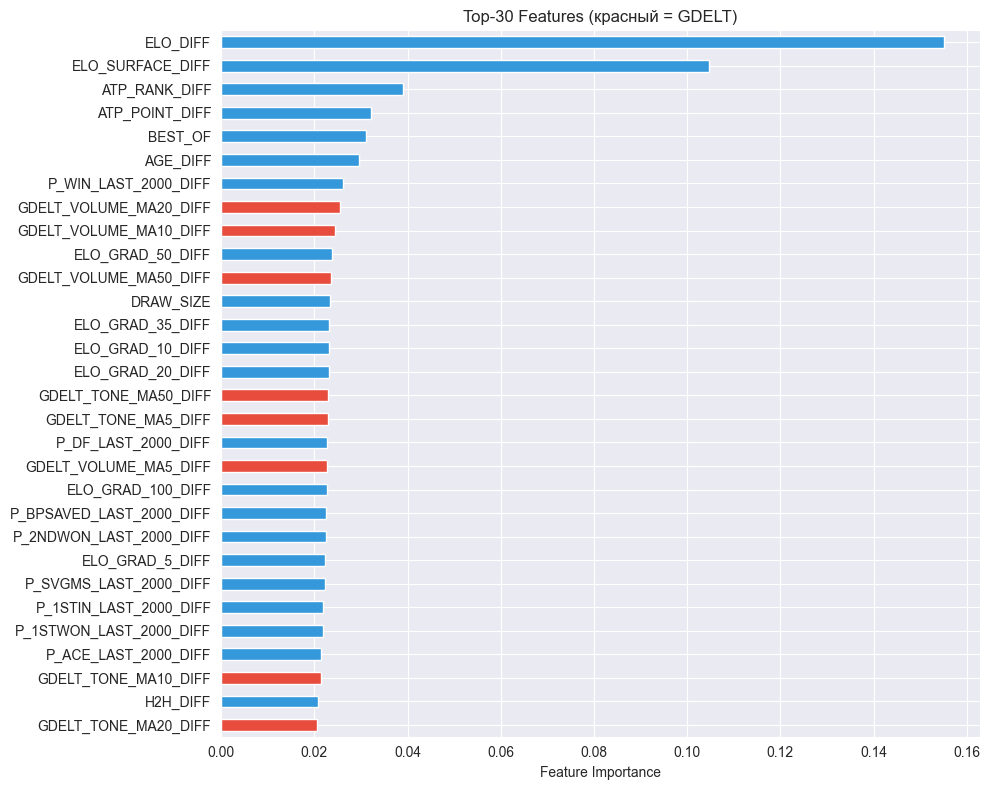


GDELT feature importances:
  GDELT_VOLUME_MA20_DIFF: 0.0256
  GDELT_VOLUME_MA10_DIFF: 0.0244
  GDELT_VOLUME_MA50_DIFF: 0.0236
  GDELT_TONE_MA50_DIFF: 0.0230
  GDELT_TONE_MA5_DIFF: 0.0229
  GDELT_VOLUME_MA5_DIFF: 0.0228
  GDELT_TONE_MA10_DIFF: 0.0213
  GDELT_TONE_MA20_DIFF: 0.0206


In [23]:
import matplotlib.pyplot as plt

importances = pd.Series(xgb_gdelt.feature_importances_, index=all_features).sort_values(ascending=False)

# Топ-30 признаков
fig, ax = plt.subplots(figsize=(10, 8))
top30 = importances.head(30)
colors = ['#e74c3c' if 'GDELT' in f else '#3498db' for f in top30.index]
top30.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title('Top-30 Features (красный = GDELT)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Отдельно GDELT-признаки
print("\nGDELT feature importances:")
gdelt_imp = importances[importances.index.isin(gdelt_diff_cols)].sort_values(ascending=False)
for feat, imp in gdelt_imp.items():
    print(f"  {feat}: {imp:.4f}")

In [24]:
n_samples = len(df)
n_features = len(df.columns)

total_cells = n_samples * n_features
print("-" * 60)
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    non_null = df[col].count()
    null_count = n_samples - non_null
    null_percent = (null_count / n_samples) * 100
    print(f"{i:2d}. {col:<25} | {dtype:<10} | {non_null:>6,} значений | {null_count:>6,} пропусков ({null_percent:5.1f}%)")

------------------------------------------------------------
 1. Unnamed: 0                | int64      | 20,725 значений |      0 пропусков (  0.0%)
 2. match_idx                 | int64      | 20,725 значений |      0 пропусков (  0.0%)
 3. tourney_date              | datetime64[ns] | 20,725 значений |      0 пропусков (  0.0%)
 4. PLAYER_1                  | int64      | 20,725 значений |      0 пропусков (  0.0%)
 5. PLAYER_2                  | int64      | 20,725 значений |      0 пропусков (  0.0%)
 6. ATP_POINT_DIFF            | float64    | 20,725 значений |      0 пропусков (  0.0%)
 7. ATP_RANK_DIFF             | float64    | 20,725 значений |      0 пропусков (  0.0%)
 8. AGE_DIFF                  | float64    | 20,725 значений |      0 пропусков (  0.0%)
 9. HEIGHT_DIFF               | float64    | 20,725 значений |      0 пропусков (  0.0%)
10. BEST_OF                   | int64      | 20,725 значений |      0 пропусков (  0.0%)
11. DRAW_SIZE                 | float64    | 

In [25]:
df[:100]

,Unnamed: 0,match_idx,tourney_date,PLAYER_1,PLAYER_2,ATP_POINT_DIFF,ATP_RANK_DIFF,AGE_DIFF,HEIGHT_DIFF,BEST_OF,...,P_WIN_LAST_2000_DIFF,RESULT,GDELT_TONE_MA5_DIFF,GDELT_TONE_MA10_DIFF,GDELT_TONE_MA20_DIFF,GDELT_TONE_MA50_DIFF,GDELT_VOLUME_MA5_DIFF,GDELT_VOLUME_MA10_DIFF,GDELT_VOLUME_MA20_DIFF,GDELT_VOLUME_MA50_DIFF
0,74642,74642,2017-01-02,106415,104678,-781.0,-71.0,-9.6,-23.0,3,...,-0.113831,0,0.090000,0.195000,0.140000,0.031000,-0.6,-0.6,0.70,0.18
1,74643,74643,2017-01-02,106378,124014,558.0,96.0,1.5,3.0,3,...,0.084848,1,-0.100000,0.050000,0.080000,0.224000,0.4,0.2,0.20,0.16
2,74644,74644,2017-01-02,106298,104468,571.0,10.0,-9.2,2.0,3,...,-0.073750,1,0.044444,0.062222,0.175516,0.164206,0.2,0.3,0.45,0.24
3,74645,74645,2017-01-02,104180,111577,685.0,71.0,13.4,5.0,3,...,0.127198,0,0.060000,0.080000,0.052500,0.021000,0.0,-0.1,-0.10,-0.06
4,74646,74646,2017-01-02,111200,111442,-317.0,-81.0,-2.0,2.0,3,...,0.050000,0,-0.107286,-0.088043,-0.119021,-0.119367,-15.2,-10.3,-5.95,-3.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,74737,74737,2017-01-09,104229,105449,-546.0,-28.0,6.4,-8.0,3,...,-0.097654,0,-0.056282,-0.075891,-0.085606,-0.081701,-15.6,-15.2,-9.75,-7.72
96,74738,74738,2017-01-09,105992,106058,-1078.0,-66.0,0.4,-6.0,3,...,-0.164714,0,0.161900,0.064636,0.085318,-0.030887,-33.8,-25.2,-12.95,-6.32
97,74739,74739,2017-01-09,105311,105454,882.0,280.0,0.7,2.0,3,...,0.134848,1,-0.220000,-0.160000,-0.130000,-0.104000,-0.4,-0.2,-0.10,-0.02
98,74740,74740,2017-01-09,104898,103970,-990.0,-37.0,-5.0,16.0,3,...,-0.230492,1,0.009148,-0.165355,-0.205823,-0.268739,-29.0,-21.5,-12.85,-6.10
